In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Path to your training folder
train_path = "/content/drive/MyDrive/BrainTumorMRI"

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load dataset
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Print info
print("Classes:", train_dataset.classes)
print("Number of training images:", len(train_dataset))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of training images: 5600


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Transformations (resize, augment, normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Full dataset
train_path = "/content/drive/MyDrive/BrainTumorMRI"  # your path
full_dataset = datasets.ImageFolder(root=train_path, transform=transform)

# Split into train + validation (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Classes
class_names = full_dataset.classes
print("Classes:", class_names)
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training samples: 4480, Validation samples: 1120


In [4]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet18
resnet18_model = models.resnet18(pretrained=True)

# Freeze base layers
for param in resnet18_model.parameters():
    param.requires_grad = False

# Replace the final layer for 4 classes
num_classes = 4
resnet18_model.fc = nn.Linear(resnet18_model.fc.in_features, num_classes)

# Move to GPU
resnet18_model = resnet18_model.to(device)
print("ResNet18 ready for training!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


ResNet18 ready for training!


In [5]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18_model.fc.parameters(), lr=1e-3)

In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    best_val_acc = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        all_labels = []
        all_preds = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(predicted.cpu().numpy())

        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss / val_total)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
              f"Val Loss: {val_loss/val_total:.4f}, Val Acc: {val_acc:.4f}")

    return model, history, all_labels, all_preds

In [9]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [10]:
resnet18_model, history_resnet, val_labels, val_preds = train_model(
    resnet18_model, train_loader, val_loader, criterion, optimizer, epochs=10
)

Epoch [1/10] Train Loss: 0.4918, Train Acc: 0.8290 Val Loss: 0.4127, Val Acc: 0.8670
Epoch [2/10] Train Loss: 0.4337, Train Acc: 0.8429 Val Loss: 0.3640, Val Acc: 0.8759
Epoch [3/10] Train Loss: 0.4016, Train Acc: 0.8478 Val Loss: 0.3778, Val Acc: 0.8580
Epoch [4/10] Train Loss: 0.3798, Train Acc: 0.8560 Val Loss: 0.3589, Val Acc: 0.8679
Epoch [5/10] Train Loss: 0.3666, Train Acc: 0.8681 Val Loss: 0.3280, Val Acc: 0.8875
Epoch [6/10] Train Loss: 0.3514, Train Acc: 0.8694 Val Loss: 0.3263, Val Acc: 0.8821
Epoch [7/10] Train Loss: 0.3462, Train Acc: 0.8703 Val Loss: 0.3213, Val Acc: 0.8893
Epoch [8/10] Train Loss: 0.3356, Train Acc: 0.8795 Val Loss: 0.2984, Val Acc: 0.8911
Epoch [9/10] Train Loss: 0.3352, Train Acc: 0.8768 Val Loss: 0.3119, Val Acc: 0.8866
Epoch [10/10] Train Loss: 0.3210, Train Acc: 0.8746 Val Loss: 0.3212, Val Acc: 0.8848


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import torch

def evaluate_model_simple(model, val_loader, original_dataset):
    """
    Evaluates the model on a validation set and shows:
    - Classification report (accuracy, recall, F1-score)
    - Confusion matrix with numbers

    model: trained PyTorch model
    val_loader: DataLoader for validation data
    original_dataset: full ImageFolder dataset (to get class names)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    class_names = original_dataset.classes
    num_classes = len(class_names)

    all_labels = []
    all_preds = []

    # Collect all predictions and labels
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # ----------------------
    # Classification report
    # ----------------------
    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # ----------------------
    # Confusion matrix
    # ----------------------
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7,6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    # Add numbers inside each cell
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


Classification Report:

              precision    recall  f1-score   support

      glioma     0.8745    0.8812    0.8779       261
  meningioma     0.8683    0.7201    0.7873       293
     notumor     0.9636    0.9364    0.9498       283
   pituitary     0.8112    0.9717    0.8842       283

    accuracy                         0.8759      1120
   macro avg     0.8794    0.8774    0.8748      1120
weighted avg     0.8794    0.8759    0.8740      1120



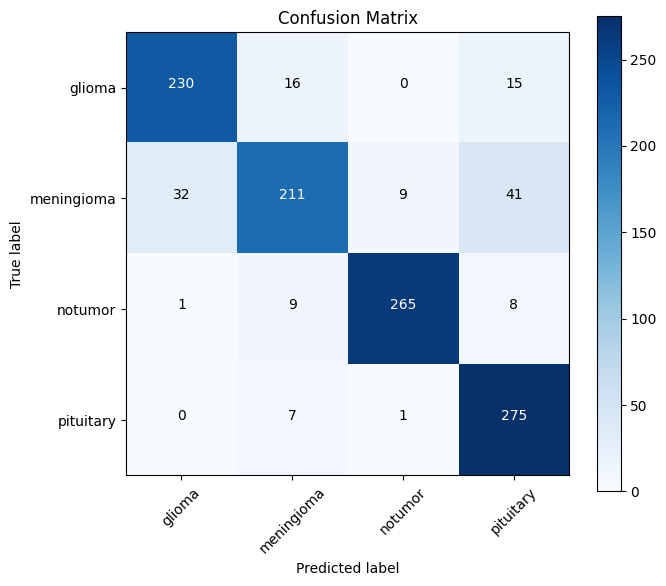

In [21]:
evaluate_model_simple(resnet18_model, val_loader, full_dataset)

In [22]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained EfficientNet-B0
efficientnet_model = models.efficientnet_b0(pretrained=True)

# Replace the classifier for 4 classes
num_features = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = nn.Linear(num_features, 4)

efficientnet_model = efficientnet_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 152MB/s]


In [23]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(efficientnet_model.parameters(), lr=1e-4)

In [24]:
# Example transforms for EfficientNet
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

In [25]:
num_epochs = 10

for epoch in range(num_epochs):
    efficientnet_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = efficientnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

Epoch 1/10 | Loss: 0.4945 | Acc: 0.8446
Epoch 2/10 | Loss: 0.1613 | Acc: 0.9460
Epoch 3/10 | Loss: 0.0899 | Acc: 0.9723
Epoch 4/10 | Loss: 0.0536 | Acc: 0.9817
Epoch 5/10 | Loss: 0.0481 | Acc: 0.9844
Epoch 6/10 | Loss: 0.0314 | Acc: 0.9893
Epoch 7/10 | Loss: 0.0299 | Acc: 0.9886
Epoch 8/10 | Loss: 0.0229 | Acc: 0.9929
Epoch 9/10 | Loss: 0.0203 | Acc: 0.9938
Epoch 10/10 | Loss: 0.0174 | Acc: 0.9942



Classification Report:

              precision    recall  f1-score   support

      glioma     0.9923    0.9847    0.9885       261
  meningioma     0.9829    0.9795    0.9812       293
     notumor     0.9965    0.9929    0.9947       283
   pituitary     0.9826    0.9965    0.9895       283

    accuracy                         0.9884      1120
   macro avg     0.9885    0.9884    0.9885      1120
weighted avg     0.9884    0.9884    0.9884      1120



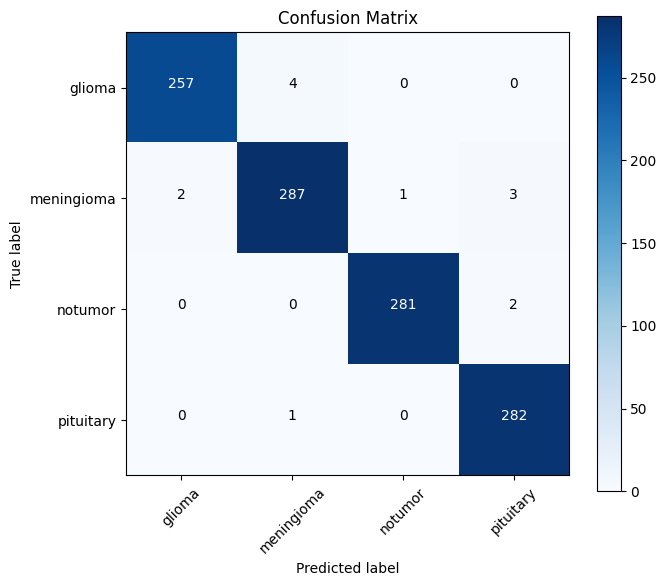

In [26]:
evaluate_model_simple(efficientnet_model, val_loader, full_dataset)

In [27]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained DenseNet121
densenet_model = models.densenet121(pretrained=True)

# Replace the classifier for 4 classes
num_features = densenet_model.classifier.in_features
densenet_model.classifier = nn.Linear(num_features, 4)

densenet_model = densenet_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 56.0MB/s]


In [28]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(densenet_model.parameters(), lr=1e-4)

In [29]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

In [30]:
num_epochs = 10

for epoch in range(num_epochs):
    densenet_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = densenet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

Epoch 1/10 | Loss: 0.2971 | Acc: 0.8991
Epoch 2/10 | Loss: 0.0947 | Acc: 0.9696
Epoch 3/10 | Loss: 0.0610 | Acc: 0.9810
Epoch 4/10 | Loss: 0.0438 | Acc: 0.9868
Epoch 5/10 | Loss: 0.0304 | Acc: 0.9917
Epoch 6/10 | Loss: 0.0228 | Acc: 0.9931
Epoch 7/10 | Loss: 0.0161 | Acc: 0.9964
Epoch 8/10 | Loss: 0.0253 | Acc: 0.9935
Epoch 9/10 | Loss: 0.0192 | Acc: 0.9933
Epoch 10/10 | Loss: 0.0153 | Acc: 0.9949



Classification Report:

              precision    recall  f1-score   support

      glioma     0.9847    0.9847    0.9847       261
  meningioma     0.9794    0.9727    0.9760       293
     notumor     0.9964    0.9894    0.9929       283
   pituitary     0.9826    0.9965    0.9895       283

    accuracy                         0.9857      1120
   macro avg     0.9858    0.9858    0.9858      1120
weighted avg     0.9857    0.9857    0.9857      1120



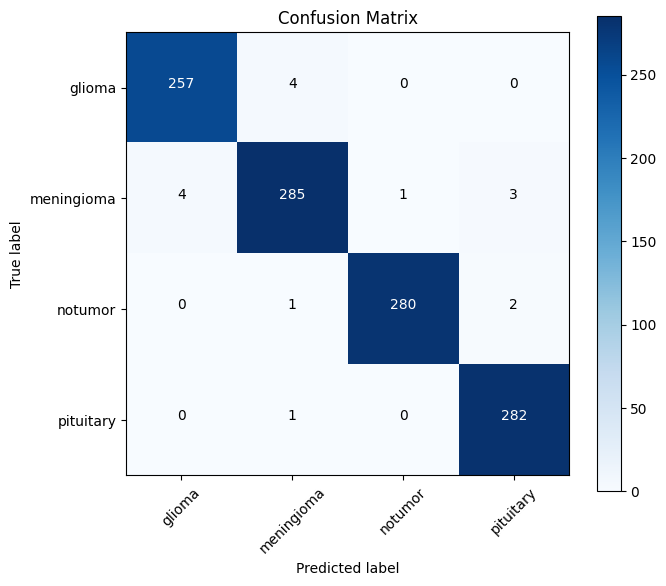

In [31]:
evaluate_model_simple(densenet_model, val_loader, full_dataset)

In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import torch

def get_model_preds(model, val_loader, num_classes):
    """Return true labels and predicted probabilities"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    y_true = label_binarize(all_labels, classes=range(num_classes))
    y_score = np.array(all_probs)
    return y_true, y_score

In [38]:
num_classes = 4

# Get true labels and probabilities for all models
y_true_r, y_score_r = get_model_preds(resnet18_model, val_loader, num_classes)
y_true_e, y_score_e = get_model_preds(efficientnet_model, val_loader, num_classes)
y_true_d, y_score_d = get_model_preds(densenet_model, val_loader, num_classes)

def compute_macro_roc(y_true, y_score, num_classes):
    """Compute macro-average ROC curve and AUC"""
    # ROC per class
    fpr_list = []
    tpr_list = []
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        fpr_list.append(fpr)
        tpr_list.append(tpr)

    # Interpolate all ROC curves at common FPR points
    all_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(num_classes):
        mean_tpr += np.interp(all_fpr, fpr_list[i], tpr_list[i])
    mean_tpr /= num_classes
    macro_auc = auc(all_fpr, mean_tpr)
    return all_fpr, mean_tpr, macro_auc

# Compute macro ROC for each model
fpr_r, tpr_r, auc_r = compute_macro_roc(y_true_r, y_score_r, num_classes)
fpr_e, tpr_e, auc_e = compute_macro_roc(y_true_e, y_score_e, num_classes)
fpr_d, tpr_d, auc_d = compute_macro_roc(y_true_d, y_score_d, num_classes)

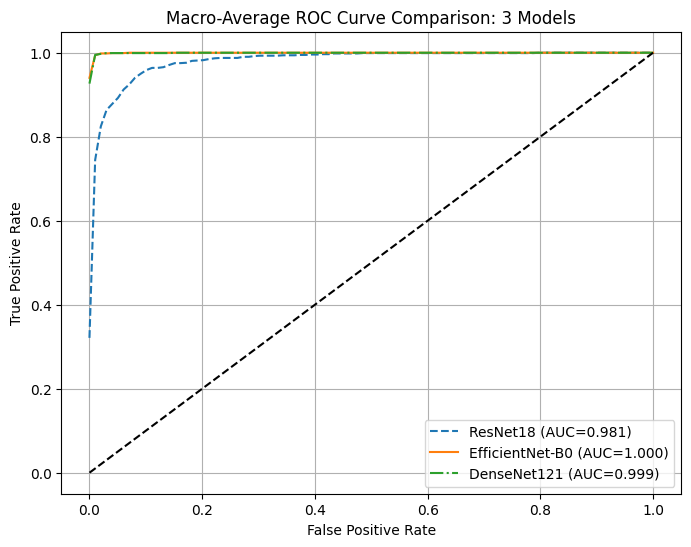

In [39]:
# Plot comparison
plt.figure(figsize=(8,6))
plt.plot(fpr_r, tpr_r, linestyle='--', label=f"ResNet18 (AUC={auc_r:.3f})")
plt.plot(fpr_e, tpr_e, linestyle='-', label=f"EfficientNet-B0 (AUC={auc_e:.3f})")
plt.plot(fpr_d, tpr_d, linestyle='-.', label=f"DenseNet121 (AUC={auc_d:.3f})")
plt.plot([0,1],[0,1],'k--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve Comparison: 3 Models")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [40]:
import torch
import os

# Path to save the model
save_path = "/content/drive/MyDrive/brain_tumor_models/efficientnet_model.pth"

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the model weights
torch.save(efficientnet_model.state_dict(), save_path)

print(f"EfficientNet-B0 model saved at: {save_path}")

EfficientNet-B0 model saved at: /content/drive/MyDrive/brain_tumor_models/efficientnet_model.pth
